In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, roc_curve, auc
from sklearn.linear_model import LinearRegression

### Cell FGtMqI_cH5lu: Import Libraries

This cell imports all the necessary Python libraries for data manipulation, analysis, machine learning, and visualization.

*   **`pandas` and `numpy`**: Fundamental libraries for data handling and numerical operations.
*   **`matplotlib.pyplot` and `seaborn`**: Used for creating static, interactive, and animated visualizations in Python.
*   **`sklearn.model_selection`**: Provides tools for splitting data into training and testing sets.
*   **`sklearn.compose`**: Used to apply different transformers to different columns of data.
*   **`sklearn.preprocessing.OneHotEncoder`**: Converts categorical features into a one-hot encoded numerical format.
*   **`sklearn.pipeline.Pipeline`**: Helps to chain multiple processing steps (like preprocessing and model training) into a single scikit-learn object.
*   **`sklearn.ensemble.RandomForestClassifier`**: The machine learning model chosen for churn prediction.
*   **`sklearn.metrics`**: Contains various functions to evaluate the performance of classification models, such as accuracy, F1-score, ROC-AUC, classification report, confusion matrix, precision, recall, and ROC curve.
*   **`sklearn.linear_model.LinearRegression`**: Used later to calculate the equity slope.

In [ ]:
#Loading the data
features = pd.read_csv("features_data.csv")
equity = pd.read_csv("equity_value_data.csv")

features.head()

,risk_tolerance,investment_experience,liquidity_needs,platform,time_spent,instrument_type_first_traded,first_deposit_amount,time_horizon,user_id
0,high_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,33.129417,stock,40.0,med_time_horizon,895044c23edc821881e87da749c01034
1,med_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,16.573517,stock,200.0,short_time_horizon,458b1d95441ced242949deefe8e4b638
2,med_risk_tolerance,limited_investment_exp,very_important_liq_need,iOS,10.008367,stock,25.0,long_time_horizon,c7936f653d293479e034865db9bb932f
3,med_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,1.031633,stock,100.0,short_time_horizon,b255d4bd6c9ba194d3a350b3e76c6393
4,high_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,8.187250,stock,20.0,long_time_horizon,4a168225e89375b8de605cbc0977ae91


### Cell 08rVp6H0H-81: Load Data

This cell loads two CSV files, `features_data.csv` and `equity_value_data.csv`, into pandas DataFrames named `features` and `equity`, respectively. It then displays the first few rows of the `features` DataFrame using `features.head()` to give a preview of its content.

In [ ]:
equity["timestamp"] = pd.to_datetime(equity["timestamp"]).dt.date
equity["timestamp"] = pd.to_datetime(equity["timestamp"])

### Cell IXJ1ofYQH-6n: Process Equity Timestamps

This cell processes the `timestamp` column in the `equity` DataFrame. It first converts the `timestamp` column to datetime objects and extracts only the date part. Then, it converts them back into full datetime objects. This ensures consistency and proper handling of dates for subsequent time-series analysis or calculations.

In [ ]:
#Creating Churn Labels

START_DATE = pd.to_datetime("2016-08-16")
END_DATE = pd.to_datetime("2017-08-18")
CHURN_DAYS = 28

def check_churn(user_dates):
    """
    A user churns if they previously had >= $10,
    then has 28+ consecutive calendar days below $10.

    Since the equity file only shows days with equity >= $10,
    missing days are treated as days below $10.
    """
    user_dates = sorted(user_dates)

    if len(user_dates) == 0:
        return 0

    # Check gaps between known >= $10 days
    for i in range(1, len(user_dates)):
        gap = (user_dates[i] - user_dates[i - 1]).days - 1

        if gap >= CHURN_DAYS:
            return 1

    # Check final gap from last known >= $10 day to dataset end
    final_gap = (END_DATE - user_dates[-1]).days

    if final_gap >= CHURN_DAYS:
        return 1

    return 0


churn_labels = (
    equity.groupby("user_id")["timestamp"]
    .apply(check_churn)
    .reset_index()
)

churn_labels.columns = ["user_id", "churned"]

### Cell 3OvlTalTH-4g: Create Churn Labels

This cell defines the criteria for user churn and applies it to create churn labels.

*   **`START_DATE`, `END_DATE`, `CHURN_DAYS`**: These constants define the analysis period and the duration (28 days) for which a user must have less than $10 in equity to be considered churned.
*   **`check_churn(user_dates)` function**: This function takes a list of dates when a user had equity >= $10. It then checks for gaps between these dates. If a gap (or the gap from the last active date to the `END_DATE`) is 28 days or more, the user is labeled as churned.
*   **`churn_labels` DataFrame**: This DataFrame is created by grouping the `equity` data by `user_id` and applying the `check_churn` function to each user's `timestamp` data. The resulting DataFrame contains `user_id` and a `churned` flag (0 for not churned, 1 for churned).

In [ ]:
#b: before building the classifier I am merging the datasets. I am using pd.merge. I am doing a left merge
data = features.merge(churn_labels, on="user_id", how="left")

# Users with no equity records are treated as not churned here.
data["churned"] = data["churned"].fillna(0).astype(int)

### Cell Iu4P-_kZH-2f: Merge Data and Handle Missing Churn Labels

This cell merges the `features` DataFrame with the `churn_labels` DataFrame.

*   **`data = features.merge(churn_labels, on='user_id', how='left')`**: A left merge is performed on the `user_id` column, meaning all users from the `features` DataFrame are kept, and their corresponding `churned` status is added. If a user from `features` does not have an entry in `churn_labels` (e.g., no equity records), their `churned` value will be `NaN`.
*   **`data['churned'] = data['churned'].fillna(0).astype(int)`**: Any `NaN` values in the `churned` column (representing users who had no equity records) are filled with 0 (assuming they are not churned as per the problem definition) and then converted to integer type.

In [ ]:
total_users = len(data)
churned_users = data["churned"].sum()
churn_rate = churned_users / total_users * 100

print("Part A")
print("Total users:", total_users)
print("Churned users:", churned_users)
print(f"Churn rate: {churn_rate:.2f}%")

Part A
Total users: 5584
Churned users: 1005
Churn rate: 18.00%


### Cell RkGW1MA4H-0V: Calculate and Display Churn Rate

This cell calculates and prints the overall churn rate from the combined `data` DataFrame.

*   It counts the `total_users` (total rows in `data`).
*   It sums the `churned` column to get the `churned_users` count.
*   The `churn_rate` is calculated as `(churned_users / total_users) * 100`.
*   Finally, it prints these statistics in a user-friendly format, showing the total users, churned users, and the churn rate percentage.

In [ ]:
# Calculate equity_volatility for each user
equity_volatility = equity.groupby('user_id')['close_equity'].std().reset_index()
equity_volatility.columns = ['user_id', 'equity_volatility']

# Merge this new feature into the 'data' DataFrame
data = data.merge(equity_volatility, on='user_id', how='left')

# Fill NaN values for equity_volatility (e.g., users with only one equity record won't have a std dev)
data['equity_volatility'] = data['equity_volatility'].fillna(0)

print("DataFrame with new 'equity_volatility' feature:")
display(data.head())

DataFrame with new 'equity_volatility' feature:


,risk_tolerance,investment_experience,liquidity_needs,platform,time_spent,instrument_type_first_traded,first_deposit_amount,time_horizon,user_id,churned,equity_volatility
0,high_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,33.129417,stock,40.0,med_time_horizon,895044c23edc821881e87da749c01034,0,10.739414
1,med_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,16.573517,stock,200.0,short_time_horizon,458b1d95441ced242949deefe8e4b638,0,26.057862
2,med_risk_tolerance,limited_investment_exp,very_important_liq_need,iOS,10.008367,stock,25.0,long_time_horizon,c7936f653d293479e034865db9bb932f,0,0.000000
3,med_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,1.031633,stock,100.0,short_time_horizon,b255d4bd6c9ba194d3a350b3e76c6393,0,11.967710
4,high_risk_tolerance,limited_investment_exp,very_important_liq_need,Android,8.187250,stock,20.0,long_time_horizon,4a168225e89375b8de605cbc0977ae91,0,146.789955


### Cell YRmxoZdfH-wJ: Calculate and Add Equity Volatility

This cell computes a new feature, `equity_volatility`, which measures the standard deviation of a user's `close_equity` over time.

*   **`equity.groupby('user_id')['close_equity'].std()`**: Groups the `equity` DataFrame by `user_id` and calculates the standard deviation of `close_equity` for each user.
*   **`data = data.merge(equity_volatility, on='user_id', how='left')`**: Merges this new `equity_volatility` feature into the main `data` DataFrame.
*   **`data['equity_volatility'] = data['equity_volatility'].fillna(0)`**: Fills any `NaN` values in the `equity_volatility` column with 0. This might occur for users who have only one equity record, making standard deviation undefined.

In [ ]:
avg_equity = (
    equity.groupby("user_id")["close_equity"]
    .mean()
    .reset_index()
    .rename(columns={"close_equity": "avg_equity"})
)

max_equity = (
    equity.groupby("user_id")["close_equity"]
    .max()
    .reset_index()
    .rename(columns={"close_equity": "max_equity"})
)

min_equity = (
    equity.groupby("user_id")["close_equity"]
    .min()
    .reset_index()
    .rename(columns={"close_equity": "min_equity"})
)

equity_range = (
    equity.groupby("user_id")["close_equity"]
    .agg(lambda x: x.max() - x.min())
    .reset_index()
    .rename(columns={"close_equity": "equity_range"})
)

active_days = (
    equity.groupby("user_id")
    .size()
    .reset_index(name="active_days")
)

equity_sorted = equity.sort_values(["user_id", "timestamp"])

daily_change = (
    equity_sorted
    .groupby("user_id")["close_equity"]
    .diff()
)

equity_sorted["daily_change"] = daily_change

avg_daily_change = (
    equity_sorted
    .groupby("user_id")["daily_change"]
    .mean()
    .fillna(0)
    .reset_index()
    .rename(columns={"daily_change": "avg_daily_change"})
)

### Cell mpk4mnTuH-t6: Generate Additional Equity-Derived Features

This cell generates several new features based on the `close_equity` data, which are potentially useful for predicting churn.

*   **`avg_equity`**: Calculates the average `close_equity` for each user.
*   **`max_equity`**: Finds the maximum `close_equity` for each user.
*   **`min_equity`**: Finds the minimum `close_equity` for each user.
*   **`equity_range`**: Computes the difference between the maximum and minimum `close_equity` for each user.
*   **`active_days`**: Counts the number of unique days a user had equity records.
*   **`daily_change`**: Calculates the day-over-day change in `close_equity` for each user.
*   **`avg_daily_change`**: Computes the average `daily_change` for each user, filling any `NaN` values with 0 (e.g., for users with insufficient daily changes).

In [ ]:
from sklearn.linear_model import LinearRegression

def compute_slope(group):
    if len(group) < 2:
        return 0

    X = np.arange(len(group)).reshape(-1, 1)
    y = group["close_equity"].values

    model = LinearRegression()
    model.fit(X, y)

    return model.coef_[0]

equity_slope = (
    equity.sort_values(["user_id", "timestamp"])
    .groupby("user_id")
    .apply(compute_slope)
    .reset_index(name="equity_slope")
)

/tmp/ipykernel_438/617429286.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_slope)


### Cell EwH15Qx5H-rc: Calculate Equity Slope

This cell defines and applies a function to calculate the `equity_slope` for each user, indicating the general trend of their equity over time.

*   **`compute_slope(group)` function**:
    *   Takes a group (DataFrame slice for a single user) of equity data.
    *   If the user has fewer than two equity records, it returns 0 (slope cannot be calculated).
    *   Otherwise, it uses `LinearRegression` to fit a line to the `close_equity` values over time (represented by an index `X`).
    *   Returns the coefficient (slope) of the fitted line.
*   **`equity_slope` DataFrame**: This DataFrame is created by grouping the sorted `equity` data by `user_id` and applying the `compute_slope` function to each group. This helps capture whether a user's equity is trending upwards, downwards, or remaining relatively flat.

In [ ]:
new_features = (
    avg_equity
    .merge(max_equity, on="user_id")
    .merge(min_equity, on="user_id")
    .merge(equity_range, on="user_id")
    .merge(active_days, on="user_id")
    .merge(avg_daily_change, on="user_id")
    .merge(equity_slope, on="user_id")
)

data = data.merge(new_features, on="user_id", how="left")

data.fillna(0, inplace=True)

### Cell r0QKYewLH-ot: Consolidate New Features

This cell consolidates all the newly engineered features into the main `data` DataFrame.

*   **`new_features = avg_equity.merge(...).merge(...)`**: It sequentially merges `avg_equity`, `max_equity`, `min_equity`, `equity_range`, `active_days`, `avg_daily_change`, and `equity_slope` into a single `new_features` DataFrame, all based on `user_id`.
*   **`data = data.merge(new_features, on='user_id', how='left')`**: The `new_features` DataFrame is then merged into the main `data` DataFrame using a left merge.
*   **`data.fillna(0, inplace=True)`**: Any remaining `NaN` values in the `data` DataFrame (which could arise from merges where a user might not have data for a specific feature) are filled with 0. This ensures the DataFrame is clean for model training.

In [ ]:
# Prepare X and y from the 'data' DataFrame, explicitly dropping 'active_days'
drop_cols = ["user_id", "churned", "active_days"]

# Ensure 'churn_probability' and 'predicted_churn' are dropped if they exist
for col in ["churn_probability", "predicted_churn"]:
    if col in data.columns:
        drop_cols.append(col)

X_data = data.drop(columns=drop_cols)
y_labels = data["churned"]

# Re-identify feature types since X_data has changed
categorical_features = X_data.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_data.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Re-split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

# Rebuild model with the previously optimized parameters
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample", # Using best_model's class_weight
    max_depth=5,
    min_samples_leaf=1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

# Train the pipeline on the data without 'active_days'
pipeline.fit(X_train, y_train)

# Evaluate the model
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

print("\nPerformance of Model without 'active_days':")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Performance of Model without 'active_days':
Accuracy: 0.6705461056401074
F1 Score: 0.42138364779874216
ROC-AUC: 0.7197256077690152

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77       916
           1       0.31      0.67      0.42       201

    accuracy                           0.67      1117
   macro avg       0.60      0.67      0.60      1117
weighted avg       0.79      0.67      0.71      1117


Confusion Matrix:
[[615 301]
 [ 67 134]]


### Cell 33944GUrH-k6: Model Training and Evaluation

This cell prepares the data for machine learning, trains a `RandomForestClassifier` model, and evaluates its performance.

*   **Data Preparation**:
    *   `X_data` (features) and `y_labels` (target variable, 'churned') are separated from the `data` DataFrame. Columns like `user_id` and `active_days` are dropped from `X_data`.
    *   `categorical_features` and `numeric_features` are identified dynamically.
*   **`ColumnTransformer`**: This preprocessor is set up to apply `OneHotEncoder` to categorical features and pass numerical features through without transformation.
*   **Data Split**: The data is split into training (80%) and testing (20%) sets using `train_test_split`, ensuring stratification to maintain the proportion of churned users in both sets.
*   **Model Initialization**: A `RandomForestClassifier` is initialized with specific hyperparameters (e.g., `n_estimators=300`, `class_weight='balanced_subsample'`) which were likely optimized in a previous step.
*   **`Pipeline`**: A scikit-learn `Pipeline` is created to combine the `preprocessor` and the `RandomForestClassifier` model. This streamlines the preprocessing and training steps.
*   **Model Training**: The `pipeline` is trained on the `X_train` and `y_train` data.
*   **Model Evaluation**:
    *   `y_prob` (predicted probabilities for churn) and `y_pred` (predicted class labels) are generated on the `X_test` data.
    *   The model's performance is evaluated and printed using `accuracy_score`, `f1_score`, `roc_auc_score`, `classification_report`, and `confusion_matrix`. These metrics provide a comprehensive view of how well the model performs in identifying churned users.

### Feature Importance
Let's examine the importance of each feature in the trained Random Forest Classifier model. This helps us understand which factors are most influential in predicting user churn.

### Cell 5bffb26c: Feature Importance Introduction

This is a markdown cell that serves as a heading, introducing the section for analyzing feature importance. It highlights the purpose of this analysis: to understand which factors are most influential in predicting user churn.

In [ ]:
# Get feature importances from the trained Random Forest model
rf_model = pipeline.named_steps['model']
feature_importances = rf_model.feature_importances_

# Get feature names from the preprocessor
onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(onehot_features) + list(numeric_features)

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(feature_importance_df.head(10))

Top 10 Feature Importances:


,Feature,Importance
32,min_equity,0.232925
30,avg_equity,0.115226
31,max_equity,0.093786
33,equity_range,0.087920
27,time_spent,0.084129
34,avg_daily_change,0.082463
35,equity_slope,0.074157
29,equity_volatility,0.067475
28,first_deposit_amount,0.058880
0,risk_tolerance_high_risk_tolerance,0.034077


### Cell eb2f59b3: Calculate and Display Feature Importance

This cell calculates and displays the importance of each feature in the trained Random Forest Classifier.

*   **`rf_model = pipeline.named_steps['model']`**: Extracts the trained `RandomForestClassifier` from the `pipeline`.
*   **`feature_importances = rf_model.feature_importances_`**: Retrieves the importance scores for each feature directly from the `RandomForestClassifier`.
*   **Feature Name Alignment**: It constructs a list of `all_feature_names` by combining the one-hot encoded categorical feature names (obtained from the `preprocessor`) and the numeric feature names. This is crucial for correctly mapping importance scores to their respective features.
*   **`feature_importance_df`**: A pandas DataFrame is created to store the feature names and their corresponding importance scores.
*   **Sorting and Display**: The DataFrame is sorted in descending order of `Importance`, and the top 10 most important features are printed using `display(feature_importance_df.head(10))`. This provides a quick overview of the most influential factors.

/tmp/ipykernel_438/2076864648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


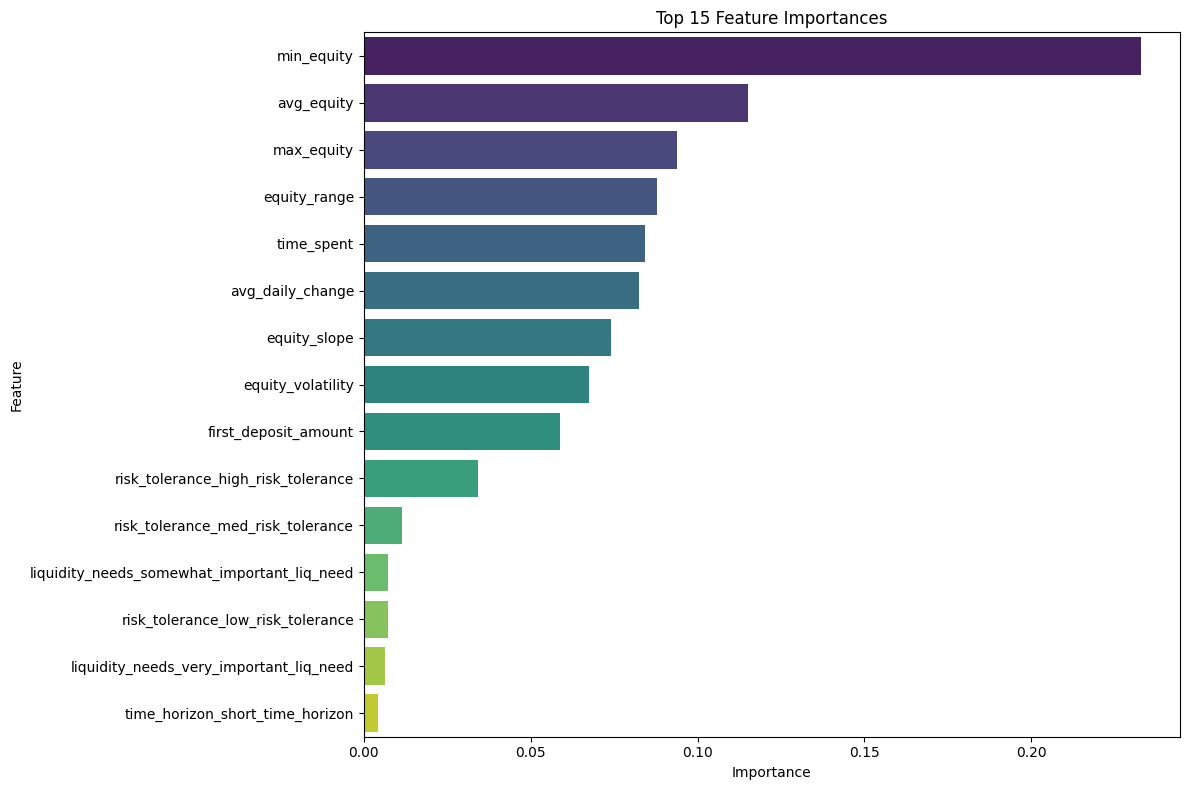

In [ ]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Cell 2e64ad19: Visualize Feature Importance

This cell visualizes the top 15 most important features using a bar plot, making it easier to interpret the model's insights.

*   **`plt.figure(figsize=(12, 8))`**: Sets up a figure with a specified size for better readability.
*   **`sns.barplot(...)`**: Uses Seaborn's `barplot` function to create a horizontal bar chart.
    *   The x-axis represents `Importance`.
    *   The y-axis represents `Feature`.
    *   `feature_importance_df.head(15)` ensures only the top 15 features are plotted.
    *   `palette='viridis'` applies a color scheme to the bars.
*   **Labels and Title**: Adds a title ('Top 15 Feature Importances') and labels for the x and y axes for clarity.
*   **`plt.tight_layout()`**: Adjusts plot parameters for a tight layout, preventing labels from overlapping.
*   **`plt.show()`**: Displays the generated plot.